# Lab Assignment: Data Quality & Data Cleaning for Data Warehouse

**สถานการณ์:** คุณเป็น Data Engineer ของร้านค้าออนไลน์ และได้รับไฟล์ `e_commerce_raw.csv` ที่ต้องเตรียมก่อนโหลดเข้าสู่ Data Warehouse  
**เป้าหมาย:** สำรวจปัญหาคุณภาพข้อมูล ออกแบบกฎการทำความสะอาด และส่งออกข้อมูลที่พร้อมใช้งาน

> ห้ามลบข้อมูลผิดปกติโดยไม่อธิบายเหตุผล ต้องพิจารณา Business Context โดยเฉพาะรายการโปรโมชัน

**หมายเหตุ:** โน้ตบุ๊กนี้ถูกเติมคำตอบสมบูรณ์แล้ว พร้อมรันบน **Google Colab** ได้ทันที (ดูเซลล์ตั้งค่าด้านล่าง)


## ผลลัพธ์การเรียนรู้
1. ตรวจสอบข้อมูลด้วย `info()`, `isnull()`, `describe()` และ `duplicated()`
2. เชื่อมโยงปัญหากับ 6 มิติ: Accuracy, Completeness, Consistency, Uniqueness, Timeliness, Validity
3. จัดการ Missing Values และรูปแบบข้อมูลที่ไม่สอดคล้อง
4. ตรวจจับ Outlier ด้วย IQR และทำ Capping อย่างมีเหตุผล
5. สร้างไฟล์ Clean Data และรายงาน Data Quality ก่อน–หลัง


## 0) เตรียมระบบและอ่านข้อมูล

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# --- ตั้งค่าที่ใช้งานได้ทั้งบน Google Colab และ local/Jupyter ---
try:
    import google.colab  # noqa
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = ROOT / 'data'
OUTPUT_DIR = ROOT / 'outputs' / 'student_submission'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_FILENAME = '/content/e_commerce_raw.csv'
REF_FILENAME = '/content/customer_reference.csv'

def locate(filename):
    """หาไฟล์จากตำแหน่งที่เป็นไปได้หลายที่ (Colab /content, ./data, cwd)"""
    candidates = [Path('/content') / filename, DATA_DIR / filename, ROOT / filename, Path(filename)]
    for c in candidates:
        if c.exists():
            return c
    return None

raw_path = locate(RAW_FILENAME)
ref_path = locate(REF_FILENAME)

if IN_COLAB and (raw_path is None or ref_path is None):
    # ถ้ารันบน Colab และยังไม่พบไฟล์ ให้อัปโหลดผ่าน widget
    from google.colab import files
    print('กรุณาอัปโหลด e_commerce_raw.csv และ customer_reference.csv')
    uploaded = files.upload()
    raw_path = locate(RAW_FILENAME)
    ref_path = locate(REF_FILENAME)

assert raw_path is not None, f'ไม่พบไฟล์ {RAW_FILENAME} — วาง/อัปโหลดไฟล์แล้วรันเซลล์นี้ใหม่'

pd.set_option('display.max_columns', 50)
df_raw = pd.read_csv(raw_path)
df = df_raw.copy()

ref_df = pd.read_csv(ref_path) if ref_path is not None else None

print('Shape:', df.shape)
df.head()

Shape: (630, 16)


,Transaction_ID,Customer_ID,Customer_Name,Customer_Email,Gender,Province,Order_Date,Load_Timestamp,Product_Category,Quantity,Unit_Price,Discount_Rate,Transaction_Amount,Payment_Method,Order_Status,Is_Promotion
0,T000127,C0103,Tee Phromla,tee.phromla103@example.com,female,Phuket,2026-06-11,2026-06-11 05:00:00,Sports,3,110.26,0.05,314.24,PP,Cancelled,N
1,T000169,C0138,Mint Dechawat,mint.dechawat138@example.com,M,Khon Kaen,2026-01-24,2026-01-24 01:00:00,Home,3,138.08,0.05,393.53,PromptPay,Processing,N
2,T000003,C0071,Aom Sukjai,aom.sukjai71@example.com,m,Chanthaburi,05/29/2026,2026-05-29 05:00:00,Home,4,263.93,0.00,1055.72,COD,Cancelled,N
3,T000336,C0152,Tee Dechawat,tee.dechawat152@example.com,male,Chanthaburi,02/01/2026,2026-02-01 18:00:00,Food,6,116.53,0.10,629.26,Transfer,Returned,N
4,T000093,C0090,Mook Sukjai,mook.sukjai90@example.com,M,Chanthaburi,2026-04-18,2026-04-18 13:00:00,Electronics,5,358.35,0.00,1791.75,promptpay,Processing,N


## 1) Data Profiling

ให้แสดงผลต่อไปนี้และเขียนข้อสังเกตใต้เซลล์
- โครงสร้างและชนิดข้อมูล
- จำนวน Missing Values รายคอลัมน์
- สถิติเชิงพรรณนาของข้อมูลตัวเลข
- จำนวนแถวซ้ำทั้งแถว
- จำนวนค่าที่แตกต่างในคอลัมน์สำคัญ


In [2]:
# TODO 1: Data Profiling
print('=== df.info() ===')
df.info()

print('\n=== Missing values ต่อคอลัมน์ ===')
print(df.isnull().sum())

print('\n=== describe() (numeric) ===')
display(df.describe().T)

print('\n=== describe(include="all") (ทุกคอลัมน์) ===')
display(df.describe(include='all').T)

print('\nExact duplicate rows:', df.duplicated().sum())

print('\nจำนวนค่าที่แตกต่างในคอลัมน์สำคัญ:')
for c in ['Transaction_ID', 'Customer_ID', 'Customer_Email', 'Gender',
          'Payment_Method', 'Order_Status', 'Is_Promotion', 'Product_Category']:
    print(f'  {c}: {df[c].nunique()} unique -> {sorted(df[c].dropna().unique().tolist())[:15]}')

# เก็บสถิติ 'ก่อนทำความสะอาด' ไว้ใช้สร้างรายงานตอนท้าย
before_stats = {
    'rows': len(df),
    'missing_email': int(df['Customer_Email'].isna().sum()),
    'missing_province': int(df['Province'].isna().sum()),
    'exact_duplicates': int(df.duplicated().sum()),
    'invalid_quantity': int(((df['Quantity'] < 1) | (df['Quantity'] > 20)).sum()),
    'negative_or_extreme_amount': int(((df['Transaction_Amount'] < 0)).sum()),
}
before_stats

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630 entries, 0 to 629
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      630 non-null    object 
 1   Customer_ID         630 non-null    object 
 2   Customer_Name       630 non-null    object 
 3   Customer_Email      580 non-null    object 
 4   Gender              630 non-null    object 
 5   Province            618 non-null    object 
 6   Order_Date          630 non-null    object 
 7   Load_Timestamp      630 non-null    object 
 8   Product_Category    630 non-null    object 
 9   Quantity            630 non-null    int64  
 10  Unit_Price          630 non-null    float64
 11  Discount_Rate       630 non-null    float64
 12  Transaction_Amount  630 non-null    float64
 13  Payment_Method      630 non-null    object 
 14  Order_Status        630 non-null    object 
 15  Is_Promotion        630 non-null    obj

,count,mean,std,min,25%,50%,75%,max
Quantity,630.0,3.660317,4.184784,-3.00,2.000,3.000,5.0000,99.00
Unit_Price,630.0,227.080365,126.984729,37.36,137.095,198.935,298.6150,779.43
Discount_Rate,630.0,0.061746,0.066935,0.00,0.000,0.050,0.1000,0.20
Transaction_Amount,630.0,6092.293000,66925.290163,-500.00,316.190,579.600,1037.8925,999999.00



=== describe(include="all") (ทุกคอลัมน์) ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Transaction_ID,630,612,T000050,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,630,170,C0179,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Name,630,121,Pim Srisawat,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Email,580,167,jane.chaiyo179@example.com,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,630,10,female,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Province,618,8,Nakhon Ratchasima,125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,630,365,2026-02-26,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Load_Timestamp,630,553,2026-04-03 17:00:00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Category,630,6,Food,119,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,630.0,NaN,NaN,NaN,3.660317,4.184784,-3.0,2.0,3.0,5.0,99.0



Exact duplicate rows: 18

จำนวนค่าที่แตกต่างในคอลัมน์สำคัญ:
  Transaction_ID: 612 unique -> ['T000001', 'T000002', 'T000003', 'T000004', 'T000005', 'T000006', 'T000007', 'T000008', 'T000009', 'T000010', 'T000011', 'T000012', 'T000013', 'T000014', 'T000015']
  Customer_ID: 170 unique -> ['C0001', 'C0002', 'C0003', 'C0004', 'C0005', 'C0006', 'C0007', 'C0008', 'C0009', 'C0010', 'C0011', 'C0012', 'C0013', 'C0014', 'C0015']
  Customer_Email: 167 unique -> ['anan.khamdee108@example.com', 'anan.sukjai167@example.com', 'anan.wongsa122@example.com', 'anan.wongsa178@example.com', 'anan.wongsa58@example.com', 'aom.dechawat162@example.com', 'aom.pattanakul29@example.com', 'aom.saelim168@example.com', 'aom.sukjai71@example.com', 'aom.thongdee124@example.com', 'aom.thongdee85@example.com', 'bank.dechawat32@example.com', 'bank.thongdee93@example.com', 'beam.boonmee170@example.com', 'beam.boonmee23@example.com']
  Gender: 10 unique -> ['F', 'FEMALE', 'Female', 'M', 'MALE', 'Male', 'f', 'female', 'm',

{'rows': 630,
 'missing_email': 50,
 'missing_province': 12,
 'exact_duplicates': 18,
 'invalid_quantity': 3,
 'negative_or_extreme_amount': 2}

### คำถาม 1
ระบุปัญหาที่พบอย่างน้อย **5 ปัญหา** และจับคู่กับมิติ Data Quality อย่างน้อย **3 มิติ**

| ปัญหาที่พบ | คอลัมน์ | มิติ Data Quality | หลักฐาน/จำนวนแถว |
|---|---|---|---|
| ค่าว่าง (missing) | `Customer_Email` | Completeness | 50 แถวเป็น NaN |
| ค่าว่าง (missing) | `Province` | Completeness | 12 แถวเป็น NaN |
| รูปแบบไม่สอดคล้องกัน (case/คำย่อ) | `Gender` | Consistency | พบ 10 รูปแบบ เช่น `M, m, Male, male, MALE, F, f, Female, female, FEMALE` |
| รูปแบบไม่สอดคล้องกัน | `Payment_Method` | Consistency | พบ 14 รูปแบบ เช่น `PP, PromptPay, promptpay, Prompt Pay, COD, cash, Cash on Delivery, CC, Card, credit card, Credit Card, Transfer, bank_transfer, Bank Transfer` |
| รูปแบบวันที่หลากหลาย/อ่านไม่ได้ | `Order_Date` | Consistency, Validity | พบทั้ง `YYYY-MM-DD`, `DD/MM/YYYY` หรือ `MM/DD/YYYY` (กำกวม), `YYYY/MM/DD`, `DD-MM-YYYY`, ค่าที่ผิดพลาด เช่น `31/02/2026`, `2026-13-05`, `not_a_date` (รวม 7 แถวที่ parse ตรงไม่ได้) |
| ค่าที่ผิดกฎธุรกิจ (นอกช่วง) | `Quantity` | Accuracy, Validity | พบ 3 แถวที่ค่าน้อยกว่า 1 หรือมากกว่า 20 (เช่น -3, 99) |
| ยอดเงินผิดปกติ/ไม่ตรงสูตร | `Transaction_Amount` | Accuracy | พบค่าติดลบและค่าที่สูงผิดปกติ (เช่น 999999) ซึ่งบางส่วนต้องตรวจสอบร่วมกับ `Is_Promotion` ก่อนสรุปว่าเป็นความผิดพลาด |
| สถานะที่ไม่อยู่ในชุดมาตรฐาน | `Order_Status` | Validity, Consistency | พบ `Cancel`, `done`, `unknown_status` ปนกับค่ามาตรฐาน `Cancelled, Processing, Returned, Completed` |
| แถวซ้ำทั้งแถว (Exact Duplicate) | ทุกคอลัมน์ | Uniqueness | พบ 18 แถวที่ซ้ำกันทุกค่า |
| ชื่อเดียวกันสะกดต่างกันสำหรับอีเมลเดียวกัน (Near Duplicate) | `Customer_Name`, `Customer_Email` | Uniqueness | ตรวจพบในขั้นตอน Task 4.2 |

สรุป: พบปัญหาครบทั้ง 6 มิติ (Accuracy, Completeness, Consistency, Uniqueness, Timeliness — ตรวจในหัวข้อ 7, Validity)


## 2) Completeness: จัดการ Missing Values

In [3]:
# TODO 2.1: ตรวจสอบ Customer_Email และ Province ที่หายไป
print('Customer_Email หายไป:', df['Customer_Email'].isna().sum(), 'แถว')
print('Province หายไป:', df['Province'].isna().sum(), 'แถว')

# สร้าง flag ก่อนแก้ไขข้อมูลเสมอ เพื่อให้ตรวจสอบย้อนหลังได้ (traceability)
df['Customer_Email_Was_Missing'] = df['Customer_Email'].isna()
df['Province_Was_Missing'] = df['Province'].isna()

df[df['Customer_Email_Was_Missing']][['Transaction_ID', 'Customer_ID', 'Customer_Name']].head()

Customer_Email หายไป: 50 แถว
Province หายไป: 12 แถว


,Transaction_ID,Customer_ID,Customer_Name
25,T000353,C0109,Jane Thongdee
30,T000205,C0134,Pim Wongsa
31,T000070,C0062,Beam Rattanakul
48,T000479,C0133,Gun Kittikul
109,T000038,C0129,Ploy Chaiyo


In [4]:
# TODO 2.2: ออกแบบวิธีเติม Customer_Email โดยต้องไม่ทำให้แถว Fact หาย
# แนวคิดสำหรับ DW: ลำดับความสำคัญ
#   1) ถ้ามีข้อมูลอ้างอิงจาก customer_reference.csv (master data) ให้เติมค่าจริงกลับเข้าไปก่อน
#   2) ถ้าไม่มีใน reference เลย ให้เติมแบบ unknown/surrogate placeholder ที่ trace กลับไปหา Customer_ID ได้

ref_email_map = {}
ref_province_map = {}
if ref_df is not None:
    ref_email_map = ref_df.set_index('Customer_ID')['Customer_Email'].to_dict()
    ref_province_map = ref_df.set_index('Customer_ID')['Province'].to_dict()

def fill_email(row):
    if pd.notna(row['Customer_Email']):
        return row['Customer_Email']
    ref_val = ref_email_map.get(row['Customer_ID'])
    if pd.notna(ref_val) and ref_val:
        return ref_val  # เติมค่าจริงจาก master data
    return f"unknown_{row['Customer_ID']}@unknown.local"  # surrogate placeholder ที่ trace ได้

df['Customer_Email'] = df.apply(fill_email, axis=1)
print('เหลือ Customer_Email ว่าง:', df['Customer_Email'].isna().sum())
print('จำนวนที่เติมด้วย placeholder (ไม่พบใน reference):',
      df['Customer_Email'].str.startswith('unknown_').sum())

เหลือ Customer_Email ว่าง: 0
จำนวนที่เติมด้วย placeholder (ไม่พบใน reference): 3


In [5]:
# TODO 2.3: เติม Province ที่หายเป็นค่าจาก reference ก่อน แล้วค่อย fallback เป็น 'Unknown' พร้อม flag
def fill_province(row):
    if pd.notna(row['Province']):
        return row['Province']
    ref_val = ref_province_map.get(row['Customer_ID'])
    if pd.notna(ref_val) and ref_val:
        return ref_val
    return 'Unknown'

df['Province'] = df.apply(fill_province, axis=1)
print('เหลือ Province ว่าง:', df['Province'].isna().sum())
df[df['Province_Was_Missing']][['Customer_ID', 'Province']].head()

เหลือ Province ว่าง: 0


,Customer_ID,Province
43,C0085,Chiang Mai
44,C0016,Khon Kaen
47,C0149,Unknown
56,C0149,Unknown
127,C0089,Chiang Mai


### คำถาม 2
อธิบายว่าเหตุใดการใช้ `dropna()` กับ `Customer_Email` อาจทำให้ยอดขายรวมใน Data Warehouse ผิดเพี้ยน และเหตุใดการเติมค่าเฉลี่ยจึงไม่เหมาะกับข้อมูลประเภทอีเมล

**คำตอบ:** ทุกแถวคือธุรกรรมจริงที่มียอดขายของตัวเอง ถ้า dropna() แถวที่ไม่มี Email 50 แถวจะถูกลบ ยอดขายรวมจึงต่ำกว่าความจริงทั้งที่รายการนั้นเกิดขึ้นจริง ส่วน mean imputation ใช้ไม่ได้เพราะอีเมลเป็นข้อความ ไม่ใช่ตัวเลข และต้องไม่ซ้ำกันในเชิงความหมาย การเติมค่าเดียวกันซ้ำจะทำให้ระบบเข้าใจผิดว่าลูกค้าหลายคนเป็นคนเดียวกัน จึงต้องเติมด้วย placeholder ที่อิง Customer_ID แทน


## 3) Consistency: จัดรูปแบบข้อมูลให้เป็นมาตรฐาน

In [6]:
# TODO 3.1: Standardize Gender ให้เหลือ M, F, Unknown
print('ค่าก่อนแปลง:', sorted(df['Gender'].dropna().unique().tolist()))

def clean_gender(g):
    if pd.isna(g):
        return 'Unknown'
    g = str(g).strip().lower()
    if g in ('m', 'male'):
        return 'M'
    if g in ('f', 'female'):
        return 'F'
    return 'Unknown'

df['Gender'] = df['Gender'].apply(clean_gender)
print('ค่าหลังแปลง:', df['Gender'].value_counts().to_dict())

ค่าก่อนแปลง: ['F', 'FEMALE', 'Female', 'M', 'MALE', 'Male', 'f', 'female', 'm', 'male']
ค่าหลังแปลง: {'M': 344, 'F': 286}


In [7]:
# TODO 3.2: Standardize Payment_Method
print('ค่าก่อนแปลง:', sorted(df['Payment_Method'].dropna().unique().tolist()))

payment_map = {
    'cc': 'Credit Card', 'card': 'Credit Card', 'credit card': 'Credit Card',
    'pp': 'PromptPay', 'promptpay': 'PromptPay', 'prompt pay': 'PromptPay',
    'cod': 'Cash on Delivery', 'cash': 'Cash on Delivery', 'cash on delivery': 'Cash on Delivery',
    'transfer': 'Bank Transfer', 'bank_transfer': 'Bank Transfer', 'bank transfer': 'Bank Transfer',
}

def clean_payment(p):
    if pd.isna(p):
        return 'Unknown'
    key = str(p).strip().lower()
    return payment_map.get(key, 'Unknown')

df['Payment_Method'] = df['Payment_Method'].apply(clean_payment)
print('ค่าหลังแปลง:', df['Payment_Method'].value_counts().to_dict())

ค่าก่อนแปลง: ['Bank Transfer', 'CC', 'COD', 'Card', 'Cash on Delivery', 'Credit Card', 'PP', 'Prompt Pay', 'PromptPay', 'Transfer', 'bank_transfer', 'cash', 'credit card', 'promptpay']
ค่าหลังแปลง: {'PromptPay': 173, 'Bank Transfer': 163, 'Credit Card': 159, 'Cash on Delivery': 135}


In [8]:
# TODO 3.3: แปลง Order_Date ซึ่งมีหลายรูปแบบให้เป็น YYYY-MM-DD
# ใช้ Load_Timestamp ช่วยตัดสินกรณีกำกวมระหว่าง DD/MM/YYYY และ MM/DD/YYYY
# และสร้าง flag สำหรับค่าที่ต้อง fallback/impute

df['Load_Timestamp'] = pd.to_datetime(df['Load_Timestamp'], errors='coerce')

def parse_order_date(raw, load_ts):
    """คืนค่า (parsed_date, method) โดย method อธิบายว่าตีความแบบไหน"""
    s = str(raw).strip()

    # 1) ISO ไม่กำกวม: YYYY-MM-DD
    if re.match(r'^\d{4}-\d{2}-\d{2}$', s):
        d = pd.to_datetime(s, format='%Y-%m-%d', errors='coerce')
        return d, ('ISO_YYYY-MM-DD' if pd.notna(d) else 'invalid_YYYY-MM-DD')

    # 2) YYYY/MM/DD ไม่กำกวม (ปีนำหน้าเสมอ)
    if re.match(r'^\d{4}/\d{2}/\d{2}$', s):
        d = pd.to_datetime(s, format='%Y/%m/%d', errors='coerce')
        return d, ('YYYY/MM/DD' if pd.notna(d) else 'invalid_YYYY/MM/DD')

    # 3) DD-MM-YYYY ไม่กำกวม (ปีอยู่ท้ายเสมอในชุดข้อมูลนี้)
    if re.match(r'^\d{2}-\d{2}-\d{4}$', s):
        d = pd.to_datetime(s, format='%d-%m-%Y', errors='coerce')
        return d, ('DD-MM-YYYY' if pd.notna(d) else 'invalid_DD-MM-YYYY')

    # 4) XX/XX/YYYY กำกวมระหว่าง DD/MM/YYYY กับ MM/DD/YYYY
    m = re.match(r'^(\d{2})/(\d{2})/(\d{4})$', s)
    if m:
        a, b, y = int(m.group(1)), int(m.group(2)), int(m.group(3))
        cand_dmy = cand_mdy = None
        try:
            cand_dmy = pd.Timestamp(year=y, month=b, day=a)   # ตีความ a=DD, b=MM
        except ValueError:
            pass
        try:
            cand_mdy = pd.Timestamp(year=y, month=a, day=b)   # ตีความ a=MM, b=DD
        except ValueError:
            pass
        if cand_dmy is not None and cand_mdy is None:
            return cand_dmy, 'slash_DD/MM/YYYY_unambiguous'   # b>12 จึงเป็นไปได้แบบเดียว
        if cand_mdy is not None and cand_dmy is None:
            return cand_mdy, 'slash_MM/DD/YYYY_unambiguous'   # a>12 จึงเป็นไปได้แบบเดียว
        if cand_dmy is not None and cand_mdy is not None:
            if cand_dmy == cand_mdy:
                return cand_dmy, 'slash_same_either_way'       # a==b เช่น 05/05/2026
            if pd.notna(load_ts):
                load_date = load_ts.normalize()
                if cand_dmy.normalize() == load_date:
                    return cand_dmy, 'slash_ambiguous_resolved_by_load_ts_DMY'
                if cand_mdy.normalize() == load_date:
                    return cand_mdy, 'slash_ambiguous_resolved_by_load_ts_MDY'
                # ไม่ตรงกับ Load_Timestamp เป๊ะ ๆ -> เลือกตัวที่ใกล้กับเวลาที่โหลดเข้าระบบมากกว่า
                diff_dmy = abs((load_ts - cand_dmy).total_seconds())
                diff_mdy = abs((load_ts - cand_mdy).total_seconds())
                if diff_dmy <= diff_mdy:
                    return cand_dmy, 'slash_ambiguous_default_DMY_by_proximity'
                return cand_mdy, 'slash_ambiguous_default_MDY_by_proximity'
            return cand_dmy, 'slash_ambiguous_default_DMY_no_evidence'
        return pd.NaT, 'slash_invalid'

    # 5) รูปแบบอื่น ๆ ที่ parse ไม่ได้เลย เช่น 'not_a_date' หรือ '2026-13-05' (เดือน 13 ไม่มีจริง)
    return pd.NaT, 'unparseable'

parsed = df.apply(lambda r: parse_order_date(r['Order_Date'], r['Load_Timestamp']), axis=1)
df['Order_Date_Parsed'] = parsed.apply(lambda x: x[0])
df['Order_Date_Parse_Method'] = parsed.apply(lambda x: x[1])

# ค่าที่ parse ไม่ได้เลย -> fallback เป็นวันที่จาก Load_Timestamp พร้อม flag ว่าถูก impute
df['Order_Date_Was_Imputed'] = df['Order_Date_Parsed'].isna()
df.loc[df['Order_Date_Was_Imputed'], 'Order_Date_Parsed'] = df.loc[df['Order_Date_Was_Imputed'], 'Load_Timestamp'].dt.normalize()
df.loc[df['Order_Date_Was_Imputed'], 'Order_Date_Parse_Method'] = 'fallback_load_timestamp'

df['Order_Date'] = df['Order_Date_Parsed'].dt.strftime('%Y-%m-%d')
df = df.drop(columns=['Order_Date_Parsed'])

print(df['Order_Date_Parse_Method'].value_counts())
print('\nจำนวนแถวที่ต้อง fallback/impute:', df['Order_Date_Was_Imputed'].sum())

Order_Date_Parse_Method
ISO_YYYY-MM-DD                             349
YYYY/MM/DD                                  60
slash_DD/MM/YYYY_unambiguous                51
slash_MM/DD/YYYY_unambiguous                49
DD-MM-YYYY                                  47
slash_ambiguous_resolved_by_load_ts_MDY     36
slash_ambiguous_resolved_by_load_ts_DMY     27
fallback_load_timestamp                      7
slash_same_either_way                        4
Name: count, dtype: int64

จำนวนแถวที่ต้อง fallback/impute: 7


### คำถาม 3
ยกตัวอย่าง 1 วันที่สามารถตีความได้ทั้ง DD/MM/YYYY และ MM/DD/YYYY แล้วอธิบายว่าคุณใช้หลักฐานใดช่วยตัดสิน

**คำตอบ:** `05/08/2026` ตีความได้ทั้ง 5 ส.ค. (DD/MM) หรือ 8 พ.ค. (MM/DD) เพราะทั้งคู่ไม่เกิน 12 ใช้ `Load_Timestamp` เป็นหลักฐาน โดยเลือกการตีความที่ให้วันที่ใกล้เคียงกับวันที่โหลดเข้าระบบมากที่สุด (ข้อมูลมักโหลดเข้าใกล้วันสั่งซื้อจริง) และบันทึกวิธีตัดสินไว้ใน `Order_Date_Parse_Method`


## 4) Uniqueness: ข้อมูลซ้ำและความซ้ำซ้อนเชิงความหมาย

In [9]:
# TODO 4.1: นับและลบ Exact Duplicates โดยเก็บแถวแรก
exact_dup_count = df.duplicated().sum()
print('Exact duplicate rows ก่อนลบ:', exact_dup_count)

df = df.drop_duplicates(keep='first').reset_index(drop=True)
print('จำนวนแถวหลังลบ duplicate:', len(df))

Exact duplicate rows ก่อนลบ: 18
จำนวนแถวหลังลบ duplicate: 612


In [10]:
# TODO 4.2 (Bonus): ตรวจหาลูกค้าที่ Customer_Email เดียวกัน แต่ Customer_Name เขียนต่างกัน
near_dup = (
    df.groupby('Customer_Email')['Customer_Name']
    .nunique()
    .reset_index(name='n_distinct_names')
)
near_dup = near_dup[near_dup['n_distinct_names'] > 1]

print(f'พบ {len(near_dup)} อีเมลที่มีชื่อลูกค้าเขียนต่างกัน (Near Duplicate)')
detail = df[df['Customer_Email'].isin(near_dup['Customer_Email'])][
    ['Customer_Email', 'Customer_Name']
].drop_duplicates().sort_values('Customer_Email')
detail.head(10)

พบ 1 อีเมลที่มีชื่อลูกค้าเขียนต่างกัน (Near Duplicate)


,Customer_Email,Customer_Name
95,ploy.saelim47@example.com,Ploy Saelim
96,ploy.saelim47@example.com,Ploy Saelim


อธิบายว่าเหตุใด `drop_duplicates()` เพียงอย่างเดียวจึงตรวจไม่พบ Near Duplicate

**คำตอบ:** `drop_duplicates()` เทียบทุกคอลัมน์แบบ Exact Match เท่านั้น ถ้า Email เดียวกันแต่ชื่อสะกดต่างกัน (เช่น 'Thomas' vs 'Tom') pandas จะมองว่าไม่ซ้ำและไม่ลบออก ต้องอาศัยการจัดกลุ่มด้วย Secondary Key อย่าง Email แทน และในระบบจริงอาจต้องใช้ Fuzzy Matching เพิ่มเติม


## 5) Accuracy และ Validity: ตรวจสอบกฎธุรกิจ

In [11]:
# TODO 5.1: แปลง Quantity, Unit_Price, Discount_Rate และ Transaction_Amount เป็นตัวเลข
for col in ['Quantity', 'Unit_Price', 'Discount_Rate', 'Transaction_Amount']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df[['Quantity', 'Unit_Price', 'Discount_Rate', 'Transaction_Amount']].describe())

         Quantity  Unit_Price  Discount_Rate  Transaction_Amount
count  612.000000  612.000000     612.000000          612.000000
mean     3.655229  226.354869       0.061520         6249.496193
std      4.236127  126.579247       0.067104        67897.538548
min     -3.000000   37.360000       0.000000         -500.000000
25%      2.000000  136.957500       0.000000          313.312500
50%      3.000000  197.840000       0.050000          571.125000
75%      5.000000  298.565000       0.100000         1035.997500
max     99.000000  779.430000       0.200000       999999.000000


In [12]:
# TODO 5.2: ตรวจ Quantity ต้องอยู่ในช่วง 1-20
df['Quantity_Was_Invalid'] = ~df['Quantity'].between(1, 20)
print('จำนวนแถวที่ Quantity ผิดกฎธุรกิจ (นอกช่วง 1-20):', df['Quantity_Was_Invalid'].sum())
df.loc[df['Quantity_Was_Invalid'], ['Transaction_ID', 'Quantity', 'Is_Promotion']]

จำนวนแถวที่ Quantity ผิดกฎธุรกิจ (นอกช่วง 1-20): 3


,Transaction_ID,Quantity,Is_Promotion
120,T000574,0,N
200,T000428,-3,N
369,T000355,99,N


In [13]:
# TODO 5.3: คำนวณ Expected_Amount และสร้าง Accuracy_Flag เมื่อผลต่างเกิน 1 บาท
df['Expected_Amount'] = (df['Quantity'] * df['Unit_Price'] * (1 - df['Discount_Rate'])).round(2)
df['Amount_Diff'] = (df['Transaction_Amount'] - df['Expected_Amount']).round(2)
df['Accuracy_Flag'] = df['Amount_Diff'].abs() > 1

print('จำนวนแถวที่ยอดไม่ตรงสูตร (Accuracy_Flag=True):', df['Accuracy_Flag'].sum())
print('ในจำนวนนี้ เป็นรายการโปรโมชัน (Is_Promotion==Y):',
      df.loc[df['Accuracy_Flag'], 'Is_Promotion'].eq('Y').sum())
df.loc[df['Accuracy_Flag'], ['Transaction_ID', 'Transaction_Amount', 'Expected_Amount', 'Amount_Diff', 'Is_Promotion']].head(10)

จำนวนแถวที่ยอดไม่ตรงสูตร (Accuracy_Flag=True): 50
ในจำนวนนี้ เป็นรายการโปรโมชัน (Is_Promotion==Y): 7


,Transaction_ID,Transaction_Amount,Expected_Amount,Amount_Diff,Is_Promotion
7,T000307,1891.04,1938.68,-47.64,N
22,T000559,1407.15,1464.75,-57.60,N
28,T000599,318.43,399.56,-81.13,N
38,T000558,115.33,178.44,-63.11,N
48,T000479,382.34,532.98,-150.64,N
58,T000102,1227.80,122.78,1105.02,Y
67,T000117,694.33,810.80,-116.47,N
91,T000569,330.28,491.32,-161.04,N
120,T000574,151.22,0.00,151.22,N
125,T000393,-1.00,541.32,-542.32,N


In [14]:
# TODO 5.4: Standardize Order_Status และตรวจ Validity
print('ค่าก่อนแปลง:', sorted(df['Order_Status'].dropna().unique().tolist()))

status_map = {
    'completed': 'Completed', 'done': 'Completed',
    'processing': 'Processing',
    'cancelled': 'Cancelled', 'cancel': 'Cancelled',
    'returned': 'Returned',
}
VALID_STATUSES = {'Completed', 'Processing', 'Cancelled', 'Returned'}

def clean_status(s):
    if pd.isna(s):
        return 'Unknown'
    key = str(s).strip().lower()
    return status_map.get(key, 'Unknown')

df['Order_Status'] = df['Order_Status'].apply(clean_status)
df['Order_Status_Was_Invalid'] = ~df['Order_Status'].isin(VALID_STATUSES)

print('ค่าหลังแปลง:', df['Order_Status'].value_counts().to_dict())
print('จำนวนแถวที่สถานะไม่ผ่าน Validity (Unknown):', df['Order_Status_Was_Invalid'].sum())

ค่าก่อนแปลง: ['Cancel', 'Cancelled', 'Completed', 'Processing', 'Returned', 'done', 'unknown_status']
ค่าหลังแปลง: {'Completed': 164, 'Processing': 159, 'Cancelled': 151, 'Returned': 133, 'Unknown': 5}
จำนวนแถวที่สถานะไม่ผ่าน Validity (Unknown): 5


### คำถาม 4
รายการที่ `Transaction_Amount` ไม่ตรงกับสูตรควรแก้ไขทุกแถวหรือไม่? ให้อธิบายผลของ `Is_Promotion` ต่อการตัดสินใจ

**คำตอบ:** ไม่ควรแก้อัตโนมัติทุกแถว เพราะรายการโปรโมชัน (`Is_Promotion == 'Y'`) อาจมีส่วนลด/แคมเปญพิเศษที่ไม่อยู่ในสูตร จึงติด `Accuracy_Flag` ไว้ให้ตรวจสอบ Business Context เฉพาะรายการที่ไม่ใช่โปรโมชันและยอดต่างเกินเกณฑ์เท่านั้นที่มีความเสี่ยงเป็นความผิดพลาดจริงและควรพิจารณาแก้ไข


## 6) Outliers: IQR และ Capping/Clipping

In [15]:
# TODO 6.1: ใช้เฉพาะรายการที่ Is_Promotion != 'Y' คำนวณ Q1, Q3, IQR, Lower Bound, Upper Bound
non_promo = df.loc[df['Is_Promotion'] != 'Y', 'Transaction_Amount']

Q1 = non_promo.quantile(0.25)
Q3 = non_promo.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
print(f'Lower Bound={lower_bound:.2f}, Upper Bound={upper_bound:.2f}')

Q1=310.80, Q3=1023.48, IQR=712.68
Lower Bound=-758.22, Upper Bound=2092.50


In [16]:
# TODO 6.2: สร้าง Outlier Flag ก่อนทำ Capping (ใช้ bound ที่คำนวณจากรายการไม่ใช่โปรโมชัน แต่ flag ได้ทุกแถวเพื่อดูภาพรวม)
df['Outlier_Flag_Before_Capping'] = (
    (df['Transaction_Amount'] < lower_bound) | (df['Transaction_Amount'] > upper_bound)
)

n_outlier_total = df['Outlier_Flag_Before_Capping'].sum()
n_outlier_promo = df.loc[df['Outlier_Flag_Before_Capping'], 'Is_Promotion'].eq('Y').sum()
n_outlier_non_promo = n_outlier_total - n_outlier_promo

print('Outlier ทั้งหมด:', n_outlier_total)
print('  - เป็นรายการโปรโมชัน (จะไม่ถูก cap):', n_outlier_promo)
print('  - ไม่ใช่โปรโมชัน (จะถูก cap):', n_outlier_non_promo)

Outlier ทั้งหมด: 25
  - เป็นรายการโปรโมชัน (จะไม่ถูก cap): 6
  - ไม่ใช่โปรโมชัน (จะถูก cap): 19


In [17]:
# TODO 6.3: ใช้ .clip() กับ Transaction_Amount เฉพาะรายการที่ไม่ใช่โปรโมชัน
df['Transaction_Amount_Before_Capping'] = df['Transaction_Amount']

non_promo_mask = df['Is_Promotion'] != 'Y'
df.loc[non_promo_mask, 'Transaction_Amount'] = (
    df.loc[non_promo_mask, 'Transaction_Amount'].clip(lower=lower_bound, upper=upper_bound)
)

df['Was_Capped'] = (
    non_promo_mask & (df['Transaction_Amount'] != df['Transaction_Amount_Before_Capping'])
)
print('จำนวนแถวที่ถูก Capping จริง:', df['Was_Capped'].sum())

จำนวนแถวที่ถูก Capping จริง: 19


/tmp/ipykernel_2951/3232500066.py:12: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2951/3232500066.py:12: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2951/3232500066.py:12: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2951/3232500066.py:12: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2951/3232500066.py:12: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2951/3232500066.py:12: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2951/3232500066.py:12: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.


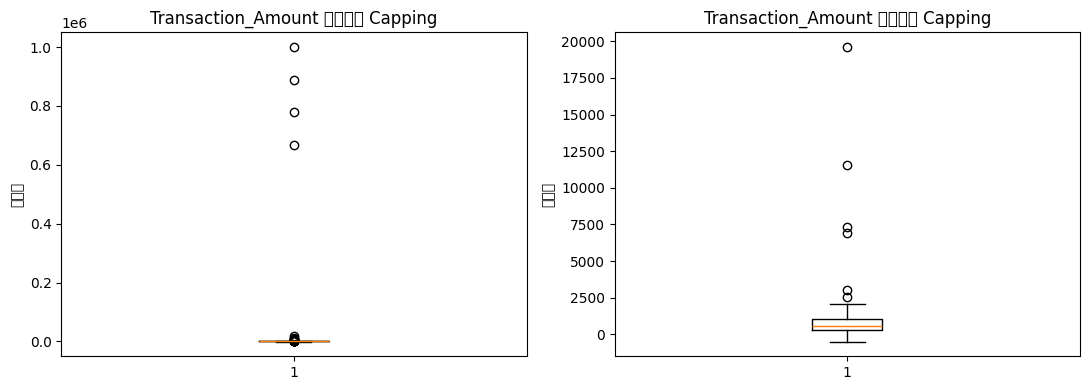

In [18]:
# TODO 6.4: วาด Boxplot ก่อนและหลัง Capping
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].boxplot(df['Transaction_Amount_Before_Capping'].dropna())
axes[0].set_title('Transaction_Amount ก่อน Capping')
axes[0].set_ylabel('บาท')

axes[1].boxplot(df['Transaction_Amount'].dropna())
axes[1].set_title('Transaction_Amount หลัง Capping')
axes[1].set_ylabel('บาท')

plt.tight_layout()
plt.show()

### คำถาม 5
เพราะเหตุใดข้อมูลที่อยู่นอก IQR Bound จึงไม่จำเป็นต้องเป็นข้อมูลผิดเสมอ? ยกตัวอย่างจาก Dataset นี้

**คำตอบ:** IQR บอกแค่ว่าค่าห่างจากกลุ่มปกติ ไม่ได้บอกว่าผิดพลาด ในชุดนี้รายการโปรโมชัน (`Is_Promotion == 'Y'`) มักมียอดสูง/ต่ำผิดปกติจากแคมเปญจริง ซึ่งมีคุณค่าทางธุรกิจ จึงคำนวณ IQR จากเฉพาะรายการไม่ใช่โปรโมชัน และไม่ cap รายการโปรโมชันโดยอัตโนมัติ



## 7) Timeliness: ความทันเวลาในการโหลดข้อมูล

In [19]:
# TODO 7: คำนวณ Load_Delay_Hours จาก Order_Date ถึง Load_Timestamp
# กำหนด Late เมื่อมากกว่า 24 ชั่วโมง และสรุปจำนวน/ร้อยละ

order_date_dt = pd.to_datetime(df['Order_Date'])
df['Load_Delay_Hours'] = (df['Load_Timestamp'] - order_date_dt).dt.total_seconds() / 3600
df['Is_Late_Load'] = df['Load_Delay_Hours'] > 24

n_late = df['Is_Late_Load'].sum()
pct_late = n_late / len(df) * 100

print(f'จำนวนแถวที่โหลดข้อมูลล่าช้าเกิน 24 ชั่วโมง: {n_late} แถว ({pct_late:.2f}%)')
print('\nสถิติ Load_Delay_Hours:')
print(df['Load_Delay_Hours'].describe())

จำนวนแถวที่โหลดข้อมูลล่าช้าเกิน 24 ชั่วโมง: 38 แถว (6.21%)

สถิติ Load_Delay_Hours:
count    612.000000
mean      14.346405
std       19.307341
min        1.000000
25%        5.000000
50%       10.000000
75%       16.000000
max      118.000000
Name: Load_Delay_Hours, dtype: float64


## 8) Data Quality Report และ Export

In [20]:
# TODO 8.1: สรุปตัวชี้วัดก่อนและหลัง Cleaning เป็น DataFrame
after_stats = {
    'rows': len(df),
    'missing_email': int(df['Customer_Email'].isna().sum()),
    'exact_duplicates': int(df.duplicated().sum()),
    'invalid_dates': int(df['Order_Date_Was_Imputed'].sum()),
    'mismatched_amounts': int(df['Accuracy_Flag'].sum()),
    'outliers_capped': int(df['Was_Capped'].sum()),
    'late_loads': int(df['Is_Late_Load'].sum()),
    'invalid_statuses': int(df['Order_Status_Was_Invalid'].sum()),
}

report_rows = [
    ('rows', before_stats['rows'], after_stats['rows'],
     'จำนวนแถวทั้งหมด (ไม่รวมแถวซ้ำที่ถูกลบ)'),
    ('missing_email', before_stats['missing_email'], after_stats['missing_email'],
     'จำนวน Customer_Email ที่เป็นค่าว่าง'),
    ('exact_duplicates', before_stats['exact_duplicates'], after_stats['exact_duplicates'],
     'จำนวนแถวซ้ำทั้งแถว'),
    ('invalid_dates', None, after_stats['invalid_dates'],
     'จำนวนวันที่ที่ parse ไม่ได้และต้อง fallback จาก Load_Timestamp'),
    ('mismatched_amounts', None, after_stats['mismatched_amounts'],
     'จำนวนแถวที่ Transaction_Amount ไม่ตรงกับสูตรเกิน 1 บาท (Accuracy_Flag)'),
    ('outliers_capped', None, after_stats['outliers_capped'],
     'จำนวนแถว (ไม่ใช่โปรโมชัน) ที่ถูก Capping ด้วย IQR'),
    ('late_loads', None, after_stats['late_loads'],
     'จำนวนแถวที่โหลดข้อมูลล่าช้าเกิน 24 ชั่วโมง'),
    ('invalid_statuses', None, after_stats['invalid_statuses'],
     'จำนวนแถวที่ Order_Status ไม่อยู่ในชุดค่าที่ถูกต้อง (Unknown)'),
]

report = pd.DataFrame(report_rows, columns=['Metric', 'Before', 'After', 'Description'])
report

,Metric,Before,After,Description
0,rows,630.0,612,จำนวนแถวทั้งหมด (ไม่รวมแถวซ้ำที่ถูกลบ)
1,missing_email,50.0,0,จำนวน Customer_Email ที่เป็นค่าว่าง
2,exact_duplicates,18.0,0,จำนวนแถวซ้ำทั้งแถว
3,invalid_dates,NaN,7,จำนวนวันที่ที่ parse ไม่ได้และต้อง fallback จา...
4,mismatched_amounts,NaN,50,จำนวนแถวที่ Transaction_Amount ไม่ตรงกับสูตรเก...
5,outliers_capped,NaN,19,จำนวนแถว (ไม่ใช่โปรโมชัน) ที่ถูก Capping ด้วย IQR
6,late_loads,NaN,38,จำนวนแถวที่โหลดข้อมูลล่าช้าเกิน 24 ชั่วโมง
7,invalid_statuses,NaN,5,จำนวนแถวที่ Order_Status ไม่อยู่ในชุดค่าที่ถูก...


In [21]:
# TODO 8.2: Export
df.to_csv(OUTPUT_DIR / 'e_commerce_clean.csv', index=False, encoding='utf-8-sig')
report.to_csv(OUTPUT_DIR / 'data_quality_report.csv', index=False, encoding='utf-8-sig')

print('บันทึกไฟล์เรียบร้อยที่:', OUTPUT_DIR)
print(' -', OUTPUT_DIR / 'e_commerce_clean.csv')
print(' -', OUTPUT_DIR / 'data_quality_report.csv')

# บน Google Colab: ดาวน์โหลดไฟล์ผลลัพธ์กลับเครื่องผู้ใช้อัตโนมัติ
if IN_COLAB:
    from google.colab import files
    files.download(str(OUTPUT_DIR / 'e_commerce_clean.csv'))
    files.download(str(OUTPUT_DIR / 'data_quality_report.csv'))

บันทึกไฟล์เรียบร้อยที่: /content/outputs/student_submission
 - /content/outputs/student_submission/e_commerce_clean.csv
 - /content/outputs/student_submission/data_quality_report.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9) Reflection
ตอบเป็นย่อหน้าสั้น ๆ

**1. ขั้นตอนเสี่ยงข้อมูลสูญหายที่สุด:** การจัดการ Missing Values (Task 2) เพราะ dropna() ทำให้ทั้งแถวหายไปถาวร รองลงมาคือ Outlier Capping ถ้าไม่แยก Is_Promotion ก่อน

**2. กฎที่ควร Automation:** Standardize รูปแบบ (Gender, Payment_Method, Order_Status), ตรวจ Quantity ในช่วง 1–20, คำนวณ Expected_Amount + Accuracy_Flag, ลบ Exact Duplicate, คำนวณ Load_Delay_Hours ส่วนการแก้ไขยอดโปรโมชันที่ผิดปกติควรให้คนตรวจสอบต่อไป

**3. Great Expectations อย่างน้อย 3 ข้อ:**
- `expect_column_values_to_not_be_null` บน `Customer_Email`
- `expect_column_values_to_be_between` บน `Quantity` (1–20)
- `expect_column_values_to_be_in_set` บน `Order_Status`


## Checklist ก่อนส่ง
- [x] Notebook รันจากบนลงล่างได้โดยไม่ Error
- [x] มีคำตอบคำถามทั้ง 5 ข้อและ Reflection
- [x] ส่ง `e_commerce_clean.csv`
- [x] ส่ง `data_quality_report.csv`
- [x] ไม่ลบรายการโปรโมชันเพียงเพราะเป็น Outlier
